<a href="https://colab.research.google.com/github/alfinoktviaan/DataScience_240401010282_AlfinOktavian/blob/main/Pertemuan12_AlfinOktavian_240401010282.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
NAMA: Alfin Oktavian

Kelas: IF403

NIM: 240401010282

Contoh transaksi:
Transaksi 1: [np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai']
Transaksi 2: [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')]
Transaksi 3: [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]

Jumlah transaksi: 50

Frekuensi tiap produk:
    Produk  Frekuensi
4    Selai         26
5      Teh         23
2  Mentega         21
7    Telur         18
0     Keju         17
1     Roti         16
3     Kopi         16
6     Susu         16
8     Gula         16
9   Sereal          9


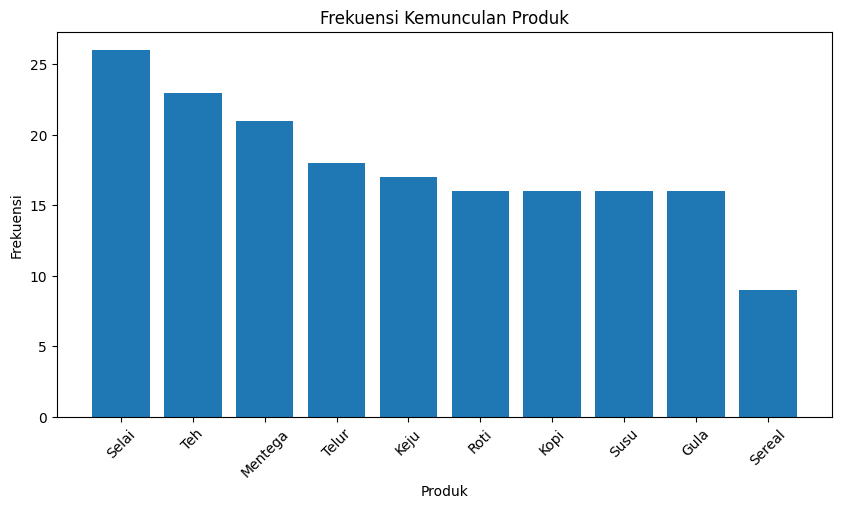

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Agar hasil acak selalu sama
np.random.seed(42)

# Daftar produk
produk = [
    'Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
    'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega'
]

# Membuat 50 transaksi
transaksi = []

for _ in range(50):
    n_item = np.random.randint(2, 6)      # 2 sampai 5 produk
    transaksi.append(
        list(np.random.choice(produk, n_item, replace=False))
    )

# Menambahkan pola tersembunyi:
# Jika ada Roti pada 20 transaksi pertama,
# maka tambahkan Selai apabila belum ada.
for i in range(20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print("Contoh transaksi:")
for i in range(3):
    print(f"Transaksi {i+1}: {transaksi[i]}")

print("\nJumlah transaksi:", len(transaksi))

# ==========================
# Eksplorasi Frekuensi Produk
# ==========================

frekuensi = {}

for transaksi_item in transaksi:
    for item in transaksi_item:
        frekuensi[item] = frekuensi.get(item, 0) + 1

df_frekuensi = pd.DataFrame(
    frekuensi.items(),
    columns=['Produk', 'Frekuensi']
).sort_values(by='Frekuensi', ascending=False)

print("\nFrekuensi tiap produk:")
print(df_frekuensi)

# Grafik
plt.figure(figsize=(10,5))
plt.bar(df_frekuensi['Produk'], df_frekuensi['Frekuensi'])
plt.title('Frekuensi Kemunculan Produk')
plt.xlabel('Produk')
plt.ylabel('Frekuensi')
plt.xticks(rotation=45)
plt.show()

In [7]:
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd

# Membuat objek TransactionEncoder
te = TransactionEncoder()

# Mengubah transaksi menjadi format one-hot encoding
te_ary = te.fit(transaksi).transform(transaksi)

# Mengubah menjadi DataFrame
df = pd.DataFrame(te_ary, columns=te.columns_)

# Menampilkan 5 baris pertama
print(df.head())

    Gula   Keju   Kopi  Mentega   Roti  Selai  Sereal   Susu    Teh  Telur
0  False   True   True     True   True   True   False  False  False  False
1  False  False   True     True   True   True   False  False   True  False
2  False  False   True    False  False  False   False   True   True  False
3  False   True  False    False  False   True   False  False   True   True
4   True   True  False     True  False  False   False   True  False  False


In [8]:
from mlxtend.frequent_patterns import apriori

# Mencoba beberapa nilai minimum support
for ms in [0.05, 0.1, 0.2]:
    freq = apriori(df, min_support=ms, use_colnames=True)
    print(f"min_support = {ms}: {len(freq)} itemset ditemukan")

# Menggunakan nilai min_support yang dianggap paling sesuai
freq_items = apriori(df, min_support=0.1, use_colnames=True)

# Mengurutkan berdasarkan nilai support terbesar
freq_items = freq_items.sort_values(by='support', ascending=False)

# Menampilkan 10 itemset teratas
print(freq_items.head(10))

min_support = 0.05: 74 itemset ditemukan
min_support = 0.1: 44 itemset ditemukan
min_support = 0.2: 13 itemset ditemukan
    support      itemsets
5      0.52       (Selai)
8      0.46         (Teh)
3      0.42     (Mentega)
9      0.36       (Telur)
1      0.34        (Keju)
0      0.32        (Gula)
2      0.32        (Kopi)
4      0.32        (Roti)
7      0.32        (Susu)
36     0.24  (Teh, Selai)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
from mlxtend.frequent_patterns import association_rules

# Membentuk aturan asosiasi
rules = association_rules(
    freq_items,
    metric='confidence',
    min_threshold=0.5
)

# Menyaring aturan dengan lift > 1
rules = rules[rules['lift'] > 1]

# Mengurutkan berdasarkan lift tertinggi
rules = rules.sort_values(
    by='lift',
    ascending=False
)

# Menampilkan 10 aturan terbaik
print(
    rules[
        [
            'antecedents',
            'consequents',
            'support',
            'confidence',
            'lift'
        ]
    ].head(10)
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

         antecedents consequents  support  confidence      lift
10       (Teh, Keju)     (Telur)     0.12    0.857143  2.380952
15  (Mentega, Selai)      (Kopi)     0.10    0.625000  1.953125
11      (Roti, Gula)     (Selai)     0.10    1.000000  1.923077
7           (Sereal)   (Mentega)     0.14    0.777778  1.851852
8       (Teh, Telur)      (Keju)     0.12    0.600000  1.764706
13     (Kopi, Selai)   (Mentega)     0.10    0.714286  1.700680
9      (Telur, Keju)       (Teh)     0.12    0.750000  1.630435
12     (Gula, Selai)      (Roti)     0.10    0.500000  1.562500
14   (Kopi, Mentega)     (Selai)     0.10    0.714286  1.373626
1             (Roti)     (Selai)     0.22    0.687500  1.322115


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [10]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Membuat katalog produk
katalog = pd.DataFrame({
    'produk': produk,
    'kategori': [
        'Bakery', 'Bakery', 'Dairy', 'Bakery', 'Dairy',
        'Dairy', 'Minuman', 'Bumbu', 'Minuman', 'Dairy'
    ]
})

# One-Hot Encoding kategori
fitur = pd.get_dummies(katalog['kategori'])

# Menghitung cosine similarity
sim_matrix = cosine_similarity(fitur)

# Fungsi rekomendasi
def rekomendasi_serupa(nama_produk, top_n=3):
    idx = katalog.index[katalog['produk'] == nama_produk][0]

    skor = list(enumerate(sim_matrix[idx]))

    # Urutkan berdasarkan similarity tertinggi
    skor = sorted(skor, key=lambda x: x[1], reverse=True)

    # Hilangkan produk itu sendiri
    skor = [s for s in skor if s[0] != idx][:top_n]

    return katalog.iloc[[i for i, _ in skor]]['produk'].tolist()

# Contoh rekomendasi
print("Mirip dengan Roti:", rekomendasi_serupa("Roti"))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Mirip dengan Roti: ['Selai', 'Sereal', 'Susu']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [11]:
produk_target = "Roti"

# Mencari aturan yang antecedent-nya mengandung produk_target
rules_terkait = rules[
    rules["antecedents"].apply(lambda x: produk_target in x)
]

print("Rekomendasi dari Association Rules:")
print(rules_terkait[["consequents", "lift"]].head())

print("\nRekomendasi dari Content-Based:")
print(rekomendasi_serupa(produk_target))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Rekomendasi dari Association Rules:
   consequents      lift
11     (Selai)  1.923077
1      (Selai)  1.322115

Rekomendasi dari Content-Based:
['Selai', 'Sereal', 'Susu']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag